# Linear Regression Project

Performing Linear Regression, beginning to end on a dataset of your choice.

---
## Part 1: Data Scoping

10 pts

**Describe this data:**
Breifly describe, what is this data about? Where is it from?

Ocean water-quality monitoring data from the Surfrider Foundation's Blue Water Task Force (BWTF) on Oʻahu. Volunteers collect seawater at specific beach sites about every two weeks, and a lab measures enterococcus, a fecal-indicator bacterium used to decide whether water is safe to swim in. We join it with daily weather history from the Open-Meteo archive (Part 4.2).

**URL:** https://bwtf.surfrider.org/report/44 (weather: https://open-meteo.com/en/docs/historical-weather-api)

**Attribution** and/or License:
Surfrider Foundation, Blue Water Task Force (Oʻahu chapter), report 44. Weather data by Open-Meteo.com (CC BY 4.0).
Answer these following questions:


*   What is one row in this dataset? Be specific about who, when, where, etc. Is this a real or simulated dataset?

One row is one seawater sample: a BWTF volunteer (`tested by`) collected water at one sampling site on Oʻahu (`site id` / `site name`, with latitude and longitude) on one date and time (`collection date`, usually a Sunday morning), and a lab reported its enterococcus count plus the volunteer's field notes (tide, weather). The columns we keep are sample_id, site_id, site_name, date, enterococcus, ent_modifier, tide, and the unsafe label. This is real data.

*   What is the target variable `y` (including units)?

`y = log1p(enterococcus) = ln(1 + count)`, where the count is enterococcus bacteria in **MPN per 100 mL** of seawater (MPN = "most probable number"). We use the log because raw counts range from 10 to 24,196 and are heavily right-skewed (Part 2.3). The 0/1 `unsafe` label (count > 130 MPN/100 mL, the Hawaii DOH standard) is saved for the project's later classifier. It is not used in this regression.

*   Does your target variable `y` depend on your feature columns `X`?

Partly. Rain washes land runoff (and sometimes sewage overflow) into the ocean, so the weather features plausibly cause bacteria spikes. The beach itself also matters, since some sites sit next to stream mouths. But many drivers are not in X (sewage leaks, animals, crowds, currents), so X can only explain part of y.

*   What population does this dataset represent? Who may have been left out?

The filtered data represents nearshore ocean water at 9 popular Oʻahu swim beaches, on the days volunteers sampled (2018–2026, about 96% on Sunday mornings). Left out: the other ~55 BWTF sites we filtered out, beaches nobody samples, the other Hawaiian islands, afternoons and nights, and especially storm days. Volunteers sample on a fixed biweekly schedule, so the dirtiest days right after heavy rain are under-represented.

*   Who would be potential user of this model? What decision might this model help them make?

Beachgoers, surfers, paddlers, and families. They would use it to decide whether to go in the water at a given beach today, or to pick a cleaner beach or wait a few days after heavy rain. Surfrider volunteers could also use it to decide which beaches to test next.

*   Are there any potential misuses of this model? "This model should not be used for..."

It should not be used for official water-quality determinations, and it must not replace DOH brown-water advisories or lab testing. A low prediction does not guarantee that the water is safe.


---
## Part 2: Exploratory Data Analysis (EDA)

10 pts

Understand, summarize, and visualize your data.

*   **Find data errors:** Spot missing values, duplicate entries, and incorrect data types early. Which columns are non-numerical?
*   **Detect outliers:** Catch extreme values or anomalies that can ruin statistical or machine learning models.
*   **Understand distributions:** Check if numerical data is normal, skewed, or spread out using summary stats and charts. Are there any columns which need to be scaled?
*   **Reveal relationships:** Find correlations and hidden connections between different variables using heatmaps or scatter plots. Remove any columns which are highly correlated with each other.


If you have a large number of feature columns `x_1`, `x_2`, ... `x_n`, you may want to select 5-15 of them focus on, though be sure to explain how reducing the number of features will impact your model.

In [1]:
# Where the data files come from. This notebook runs in two places:
#   * Colab   -> the file sits next to the notebook (an upload box opens if it isn't there yet)
#   * locally -> the file is read straight from the repo's data/raw/ folder
import os

def find_data(name):
    for path in [name, os.path.join("..", "data", "raw", name), os.path.join("data", "raw", name)]:
        if os.path.exists(path):
            return path
    try:
        from google.colab import files      # only exists inside Colab
    except ImportError:
        raise FileNotFoundError(f"{name} not found: run from the repo's notebooks/ folder "
                                "or put the file next to this notebook")
    files.upload()                          # choose `name` when the upload box appears
    return name


In [2]:
# Imports and load the raw Surfrider export (one row = one lab result for one site/day).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(find_data("surfrider_raw.csv"))
print(df.shape)
df.head()


(3713, 38)


,sample id,data entry author,state,lab id,lab name,collection date,collection time (Pacific/Honolulu),stored collectionTime,tested by,site id,...,pH,Salinity (PSU),Turbidity (NTU),Ammonia/NH3 (ppm),Nitrates/NO3 (mg/L),Nitrites/NO2 (mg/L),Nitrogen(NO3+NO2) (mg/L),Phosphate (mg/L),Dissolved Oxygen (mg/L),publication time
0,baccff0c-016f-4be9-aaa2-602e12b820e6,624e7b16-f050-4380-8f6f-d412e376796a,Hawaii,44,Oʻahu,9/6/2026,9:10:00 AM,2026-09-06T19:10:00.000Z,Karen G,1195,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08T03:08:15.725Z
1,f60244e6-3c6f-4357-aa20-61a278577347,624e7b16-f050-4380-8f6f-d412e376796a,Hawaii,44,Oʻahu,9/6/2026,9:10:00 AM,2026-09-06T19:10:00.000Z,Rossoff,859,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08T03:27:41.702Z
2,d7ac771c-10eb-4761-a222-7ed87f5d5d6c,624e7b16-f050-4380-8f6f-d412e376796a,Hawaii,44,Oʻahu,9/6/2026,9:00:00 AM,2026-09-06T19:00:00.000Z,Greg Young,858,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08T03:21:59.451Z
3,3a827787-cee0-4294-8189-a9c8e9245e6b,624e7b16-f050-4380-8f6f-d412e376796a,Hawaii,44,Oʻahu,9/6/2026,8:59:00 AM,2026-09-06T18:59:00.000Z,Ian M,979,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08T03:02:14.853Z
4,ecb8b575-bcfd-4f9c-b8d8-1a2c128e29df,624e7b16-f050-4380-8f6f-d412e376796a,Hawaii,44,Oʻahu,9/6/2026,8:50:00 AM,2026-09-06T18:50:00.000Z,Karen G,1197,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-08T03:09:58.004Z


In [3]:
# --- 2.1 Structure & data types: which columns are non-numerical? ---
print(df.dtypes)
non_numeric = df.select_dtypes(exclude="number").columns.tolist()
print("\nNon-numeric columns:", non_numeric)
# sample id / site name / modifiers / dates are text or codes, not quantities.
# Wrong types to fix: 'collection date' is text, not a date (converted in 3c); 'recent
# precipitation' is True/False stored as text; 'site id' is stored as a number but is really a
# label for a place, not a quantity (one-hot encoded in Part 4a).


sample id                                 str
data entry author                         str
state                                     str
lab id                                  int64
lab name                                  str
collection date                           str
collection time (Pacific/Honolulu)        str
stored collectionTime                     str
tested by                                 str
site id                                 int64
site name                                 str
latitude                              float64
longitude                             float64
water temperature (f)                 float64
air temperature (f)                   float64
current weather                           str
recent precipitation                   object
tide                                      str
wave height                               str
wind speed (mph)                      float64
wind direction                            str
Enterococcus modifier             

In [4]:
# --- 2.2 Missing values: how much, and does 'missing' mean unknown or none? ---
miss = df.isna().mean().mul(100).round(1).sort_values(ascending=False)
print(miss[miss > 0])
# Reading: the lab chemistry columns (pH, Turbidity, Nitrates...) are 100% blank and Salinity is
# 80% blank -> those tests were simply not run, not "unknown".
# The one column we actually need, 'Enterococcus (mpn/100mL)', is ~0.4% missing.

Phosphate (mg/L)              100.0
Nitrogen(NO3+NO2) (mg/L)      100.0
Nitrites/NO2 (mg/L)           100.0
Nitrates/NO3 (mg/L)           100.0
Ammonia/NH3 (ppm)             100.0
Turbidity (NTU)               100.0
Dissolved Oxygen (mg/L)       100.0
pH                            100.0
Ecoli (mpn/100mL)              99.8
Ecoli modifier                 99.8
Total Coliform (mpn/100mL)     99.6
Total Coliform modifier        99.6
Salinity (PSU)                 79.8
comments                       49.3
wind speed (mph)               29.2
wind direction                 25.1
water temperature (f)          24.8
air temperature (f)            10.2
wave height                     6.8
current weather                 5.1
recent precipitation            4.4
tide                            2.0
Enterococcus modifier           1.1
Enterococcus (mpn/100mL)        0.4
dtype: float64


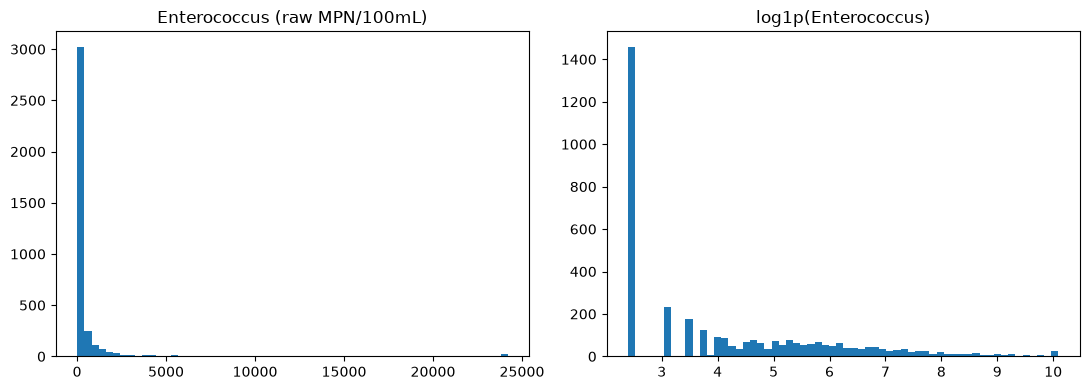

count     3697.000000
mean       619.552340
std       2495.797529
min         10.000000
25%         10.000000
50%         31.000000
75%        231.000000
max      24196.000000
Name: Enterococcus (mpn/100mL), dtype: float64

Share above the 130 MPN/100mL safety threshold: 33.0 %


In [5]:
# --- 2.3 Target distribution: enterococcus is heavily right-skewed ---
ent = pd.to_numeric(df["Enterococcus (mpn/100mL)"], errors="coerce").dropna()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(ent, bins=60);           ax[0].set_title("Enterococcus (raw MPN/100mL)")
ax[1].hist(np.log1p(ent), bins=60); ax[1].set_title("log1p(Enterococcus)")
plt.tight_layout(); plt.show()
print(ent.describe())
print("\nShare above the 130 MPN/100mL safety threshold:",
      round((ent > 130).mean() * 100, 1), "%")
# Raw counts span 4+ orders of magnitude -> a log transform is the natural scale.

In [6]:
# --- 2.4 Outliers: state the rule (IQR) but interpret with domain sense ---
q1, q3 = ent.quantile([0.25, 0.75]); iqr = q3 - q1
hi = q3 + 1.5 * iqr
print(f"IQR upper fence = {hi:.0f}; {int((ent > hi).sum())} samples above it")
# These are NOT data errors: bacteria genuinely spike into the thousands after
# storm runoff. They're rare-but-real, and they're exactly the events we care
# about -> we keep them (and model on the log scale) rather than capping.

IQR upper fence = 562; 548 samples above it


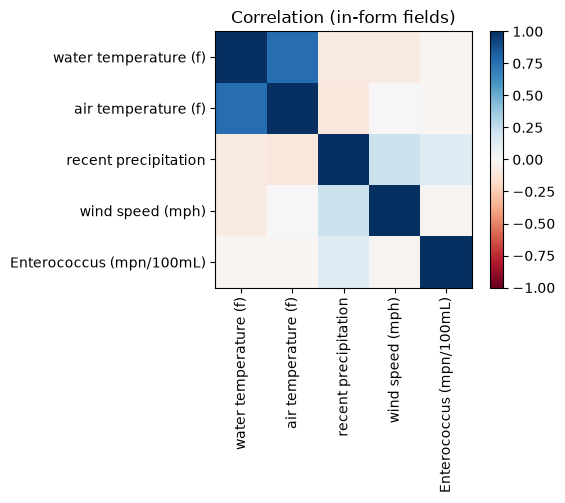

Highly correlated pairs:
 water temperature (f)  air temperature (f)    0.76

                            min      max
water temperature (f)     18.0     93.0
air temperature (f)       19.0     95.0
recent precipitation       0.0      1.0
wind speed (mph)          -2.0     40.0
Enterococcus (mpn/100mL)  10.0  24196.0


In [7]:
# --- 2.5 Relationships among the (few) populated numeric env columns ---
env = ["water temperature (f)", "air temperature (f)", "recent precipitation",
       "wind speed (mph)", "Enterococcus (mpn/100mL)"]
num = df[env].apply(pd.to_numeric, errors="coerce")
corr = num.corr()
plt.figure(figsize=(6, 5)); plt.imshow(corr, vmin=-1, vmax=1, cmap="RdBu")
plt.xticks(range(len(env)), env, rotation=90); plt.yticks(range(len(env)), env)
plt.colorbar(); plt.title("Correlation (in-form fields)"); plt.tight_layout(); plt.show()
# The in-form weather fields are sparse and inconsistent, which motivates Part 4:
# we replace them with a clean, gap-free weather history from Open-Meteo.

# Highly correlated pairs (|r| > 0.7): two columns carrying the same information.
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print("Highly correlated pairs:\n", pairs[pairs.abs() > 0.7].round(2).to_string())
# water temp vs air temp (r = 0.76) -> we'd keep at most one; 3b(ii) drops both (weak link to
# bacteria, and Open-Meteo temperature replaces them). Same idea in 4.2: Open-Meteo's rain_sum
# and precipitation_sum are identical (r = 1.00), so only rain_sum is kept.

# Do any columns need scaling? Yes -- look at how different the ranges are:
print("\n", num.agg(["min", "max"]).T.to_string())
# Temperatures are mostly 67-83 °F while enterococcus spans 10 to 24,196. The model's inputs
# (Open-Meteo rain in mm, temperature in °C, wind in km/h) differ just as much, so the continuous
# inputs are standardized in Part 4b; y itself gets a log transform instead (2.3).
# The ranges also expose data-entry errors: ~30 water and ~28 air temperatures of 18-27 "°F"
# (impossible in Hawaii -- almost certainly °C typed into a °F box) and 6 negative wind speeds
# (-0.1 and -2 mph; a speed can't be negative, so these are codes for "calm / not measured").
# All three columns are dropped in 3b(ii), so these errors never reach the model.

# Feature count: the export has 38 columns; we narrow to 7 inputs (site, tide + 5 Open-Meteo
# weather features; keep/drop reasons per column in 3b-ii). Impact: with ~1,250 rows, fewer
# features means less overfitting and weights we can actually interpret. The cost is that any
# signal in the dropped columns (e.g. the volunteer's "current weather" note) is lost, so the
# model can only explain part of y.


---
## Part 3: Data Cleaning

20 pts

### 3a · Duplicates
*   How many rows are exact duplicates of another row?
*   Are they two real records that happen to match, or one record entered twice? These are different, and which one it is determines what you do.

### 3b · Missing values
*   Which columns have missing values, and what percent?
    *   For each one: does missing mean unknown, or does it mean none? Examples: A blank pool-quality column in a housing dataset usually means there is no pool. A blank income column usually means nobody recorded it. Filling the first with an average would be wrong.
*   For each column, pick one: drop the column, drop the rows, or fill in a value.
    *   If you filled in a value, what value, and what does that choice assume about the rows you filled?
    *   Does missingness itself relate to y? If the rows with missing data have a different average y than the rows without, dropping them changes your sample.
### 3c · Outliers
*   Which values are extreme? State the rule you used to decide — IQR, standard deviations, or a domain reason.
    *   For each: Was this outlier a data error, a rare-but-real case, or a code standing in for something else? A negative number in a column measuring a physical quantity is not a small value. It means something. Find out what.
    *   Keep, cap, transform, or remove — and explain why.

In [8]:
# --- 3a Duplicates ---
print("Exact duplicate rows:", df.duplicated().sum())               # -> 0
print("Duplicate sample ids:", df["sample id"].duplicated().sum())  # -> 0
# No exact copies -- but every row gets its own random sample id, so a sample typed in twice
# would NOT show up as an exact duplicate. Look for the same site on the same day instead:
lab = df[df["Enterococcus (mpn/100mL)"].notna()]
same_day = lab[lab.duplicated(["site id", "collection date"], keep=False)]
print("Rows sharing a site + date with another row:", len(same_day),
      "in", same_day.groupby(["site id", "collection date"]).ngroups, "groups")
print(same_day.sort_values(["site id", "collection date"])[
      ["site id", "collection date", "collection time (Pacific/Honolulu)",
       "tested by", "Enterococcus (mpn/100mL)"]].to_string())

# Two different situations hide in here, and they need different treatment:
#   * SAME count (e.g. site 776 on 1/27/2019: same volunteer, same time, 10 and 10)
#       -> ONE sample entered twice. Keeping both would count it twice -> drop the extra copy.
#   * DIFFERENT counts (e.g. site 777 on 10/1/2023: 801 vs 1354 at the same minute, or site 861
#     on 3/7/2021: two volunteers 15 minutes apart) -> two REAL measurements -> keep both.
entered_twice = lab.duplicated(["site id", "collection date", "Enterococcus (mpn/100mL)"])
df = df.drop(entered_twice[entered_twice].index)
print("\nDropped", int(entered_twice.sum()), "double-entered rows ->", df.shape)


Exact duplicate rows: 0
Duplicate sample ids: 0
Rows sharing a site + date with another row: 33 in 15 groups
      site id collection date collection time (Pacific/Honolulu)                    tested by  Enterococcus (mpn/100mL)
3681      546       1/16/2002                         5:30:00 AM          LBHS Surfrider Club                      20.0
3682      546       1/16/2002                         4:30:00 AM  Laguna Beach Surfrider Club                      20.0
3415      776       1/27/2019                         8:30:00 AM                    Dan Amato                      10.0
3422      776       1/27/2019                         8:30:00 AM                    Dan Amato                      10.0
1562      777       10/1/2023                         6:25:00 AM             Christian Squire                     801.0
1563      777       10/1/2023                         6:25:00 AM             Christian Squire                    1354.0
1664      777       7/23/2023                      

In [9]:
# --- 3b Missing values: the decision per column (percentages printed in 2.2) ---
#   pH, turbidity, ammonia, nitrates,     100%     NONE: tests never run            -> drop columns
#     nitrites, nitrogen, phosphate, DO
#   E. coli, total coliform (+modifiers)  99.6-99.8% NONE: almost never tested       -> drop columns
#   Salinity                              80%      NONE: usually not measured        -> drop column
#   comments                              49%      NONE: nothing to note (free text) -> drop column
#   wind speed / wind direction           29% / 25% UNKNOWN: not recorded            -> drop columns (3b-ii)
#   water temp / air temp                 25% / 10% UNKNOWN                          -> drop columns (3b-ii)
#   wave height / current weather         7% / 5%  UNKNOWN                           -> drop columns (3b-ii)
#   recent precipitation                  4%       UNKNOWN  -> drop column (Open-Meteo rain replaces it)
#   tide                                  2%       UNKNOWN: volunteer left it blank  -> keep column, drop
#                                                  those rows in 4.5 (signal in 3b-ii, bias check in 3b-iii)
#   Enterococcus modifier                 1%       UNKNOWN -> keep as-is (a note, not a model input)
#   Enterococcus (the target)             0.4%     UNKNOWN: no lab result -> drop the 16 rows. A sample
#                                                  with no bacteria reading tells us nothing. All 16 are
#                                                  from 1999-2000, outside our 2018+ scope, so this
#                                                  can't bias the model sample.
# We never fill in values: every fill would be a guess about a real sample.
keep = {
    "sample id": "sample_id", "site id": "site_id", "site name": "site_name",
    "latitude": "latitude", "longitude": "longitude", "collection date": "date",
    "stored collectionTime": "datetime_utc",
    "Enterococcus (mpn/100mL)": "enterococcus", "Enterococcus modifier": "ent_modifier",
    "tide": "tide",
}
samples = df[list(keep)].rename(columns=keep)
samples = samples[samples["enterococcus"].notna()].copy()


In [10]:
# --- 3c Outliers + typing + label ---
# Rule: the IQR fence from 2.4 (upper fence 562 MPN/100mL, 548 samples above it), then a domain
# check of what the extreme values actually are.
ent_num = pd.to_numeric(samples["enterococcus"], errors="coerce")
print("Negative or zero counts:", int((ent_num <= 0).sum()))       # 0 -> no impossible values
# (The impossible values we did find -- °C in the °F temperature boxes and negative wind speeds,
#  see 2.5 -- are in columns we drop, so there is nothing left to fix in the kept columns.)
print(samples.assign(ent=ent_num).groupby("ent_modifier")["ent"].agg(["count", "min", "max"]))
# The modifier column ('<', '=', '>') shows some numbers are CODES, not measurements:
#   '<' with 10 (a few 20) = "below the test's detection limit": the true count is under that.
#   '>' with 24196         = "above the test's maximum": the true count is at least 24196.
# Both are rare-but-real readings, not data errors. We KEEP them at their reported value (on the
# log scale "10" vs "under 10" barely matters, and 24196 is unsafe either way) and keep the
# modifier as a separate flag. The storm spikes above the IQR fence are also real (see 2.4), so
# we TRANSFORM y with a log (4.5) instead of capping or removing them.
samples["enterococcus"] = ent_num.astype(int)
samples["date"]         = pd.to_datetime(samples["date"], format="mixed").dt.strftime("%Y-%m-%d")
samples["datetime_utc"] = samples["datetime_utc"]          # kept verbatim (ISO-8601 UTC)
samples["unsafe"]       = (samples["enterococcus"] > 130).astype(int)   # Hawaii DOH standard

samples = samples[["sample_id","site_id","site_name","latitude","longitude",
                   "date","datetime_utc","enterococcus","ent_modifier","tide","unsafe"]]
samples.to_csv("samples.csv", index=False)
print(samples.shape, "| unsafe rate:", round(samples.unsafe.mean()*100, 1), "%")
# 3686 rows = 3713 raw - 11 double entries (3a) - 16 with no bacteria reading (3b).


Negative or zero counts: 0
              count      min      max
ent_modifier                         
<              1027     10.0     20.0
=              2615     10.0  24196.0
>                21  24196.0  24196.0


(3686, 11) | unsafe rate: 33.1 %


In [11]:
# --- 3b(ii) Do the in-form weather columns carry signal? (justify keep vs. drop) ---
# Chemistry columns are 80-100% empty, so dropping them is easy. But the in-form weather fields
# (air/water temp, wave height, current weather, tide) are mostly populated -- so before
# dropping them we CHECK whether any relate to the bacteria level, instead of dropping silently.
chk = df[df["Enterococcus (mpn/100mL)"].notna()].copy()
chk["ent"]    = pd.to_numeric(chk["Enterococcus (mpn/100mL)"], errors="coerce")
chk["logent"] = np.log1p(chk["ent"])
chk["unsafe"] = (chk["ent"] > 130).astype(int)

incol = ["water temperature (f)", "air temperature (f)", "wave height",
         "current weather", "tide", "wind speed (mph)"]
print("Fill rate of the in-form weather columns (% non-missing):")
print((chk[incol].notna().mean() * 100).round(1).to_string())

print("\nLinear signal of the NUMERIC fields (corr with log-enterococcus):")
for c in ["water temperature (f)", "air temperature (f)", "wind speed (mph)"]:
    v = pd.to_numeric(chk[c], errors="coerce")
    print(f"  {c:24s} r = {v.corr(chk['logent']):+.3f}")

print("\nUnsafe rate by CATEGORICAL fields (levels with n >= 30):")
for c in ["tide", "current weather"]:
    g = chk.groupby(c)["unsafe"].agg(unsafe_pct=lambda s: round(s.mean() * 100, 1), n="size")
    print(f"\n[{c}]")
    print(g[g["n"] >= 30].sort_values("unsafe_pct", ascending=False).to_string())

# Decision -- which in-form columns to keep vs. drop (from the numbers printed above):
#   chemistry (pH, salinity, ...)  0-20% filled         -> drop (mostly empty)
#   water temp                     76% filled, r=-0.06   -> drop (negligible linear signal)
#   air temp                       90% filled, r=-0.08   -> drop (Open-Meteo temp used instead)
#   wind speed                     71% filled, r=-0.08   -> drop (Open-Meteo wind used instead)
#   current weather                95% filled            -> drop (coarse proxy for rain; Open-Meteo
#                                                           captures rainfall quantitatively)
#   tide                           98% filled            -> KEEP: outgoing 38% vs medium 21% unsafe,
#                                                           real signal with no Open-Meteo substitute
# Tide is one-hot encoded in Part 4.5. Outgoing tides flush land runoff seaward, matching the
# highest unsafe rate, so it is physically meaningful. This replaces the earlier silent drop.


Fill rate of the in-form weather columns (% non-missing):
water temperature (f)    75.7
air temperature (f)      90.3
wave height              93.7
current weather          95.2
tide                     98.0
wind speed (mph)         71.3

Linear signal of the NUMERIC fields (corr with log-enterococcus):
  water temperature (f)    r = -0.059
  air temperature (f)      r = -0.079
  wind speed (mph)         r = -0.075

Unsafe rate by CATEGORICAL fields (levels with n >= 30):

[tide]
          unsafe_pct     n
tide                      
outgoing        37.8  1545
incoming        32.6   952
high            30.0   350
low             28.9   557
medium          21.1   209

[current weather]
                 unsafe_pct     n
current weather                  
Heavy_Rain             61.0    41
Overcast               45.4   487
Light_Rain             42.2   180
Partly_Cloudy          31.5  1813
Sunny                  27.0   987


In [12]:
# --- 3b(iii) Does missingness itself relate to y? (tide is the only model input with gaps) ---
t_missing = samples["tide"].isna()
logent = np.log1p(samples["enterococcus"])
print(pd.DataFrame({
    "n":               [int(t_missing.sum()), int((~t_missing).sum())],
    "mean log1p(ent)": [logent[t_missing].mean(), logent[~t_missing].mean()],
    "unsafe %":        [samples.unsafe[t_missing].mean() * 100, samples.unsafe[~t_missing].mean() * 100],
}, index=["tide missing", "tide present"]).round(2).to_string())
# Yes, a little: samples with no tide note are CLEANER on average. Dropping them nudges our sample
# toward dirtier water. But in the 9-beach model data it is only 18 of 1,269 rows (1.4%) and moves
# mean y by about 0.01 (printed in 4.5), so we drop them rather than invent a tide value.


                 n  mean log1p(ent)  unsafe %
tide missing    73             3.69     21.92
tide present  3613             4.15     33.32


---
## Part 4: Data Engineering

25 pts

### 4a · Encode the categorical columns
*   Which columns hold text or codes rather than quantities?
    *   For each: nominal (no order — colors, regions, brands) or ordinal (ordered — poor/fair/good, income bands)?
    *   Nominal → one-hot encode. How many columns does that add?
    *   Ordinal → integer codes. State the spacing you are assuming is equal, and say whether you believe it. Is the gap from "fair" to "good" really the same size as "good" to "excellent"?
    *   Binary → 0 and 1.
    *   More than about 20 distinct values? One-hot encoding adds that many columns. Decide what to do: group the rare levels, use only the top few, or drop the column.

Warning: after one-hot encoding, drop one level from each group ("dummy variable"). If you keep all of them, those columns add up to your intercept's column of ones, your feature matrix becomes singular, and gradient descent will wander without converging.

### 4b · Scale
*   Print the range of every column after cleaning and encoding.
*   Pick a scaling method and apply it. Say why you chose it and why not the alternatives.
*   Write down the numbers your scaler computed. Store the mean and standard deviation of each column in a variable and keep it. If you ever wanted to predict for a new row, you would have to apply these same numbers to it, and a model whose scaling parameters have been lost cannot be used on anything new.
*   One-hot columns are already 0/1. Decide whether to scale them too, and justify it.

### 4c · Build at least one new feature
*   Create a new feature column
*   State the reason for the feature before you build it.
    *   Example: "I think the effect of BMI on cost is different for smokers than non-smokers, so I am building their product" is a reason. "It improved R²" is not a reason, it is a result.
*   Is your feature computed from y, directly or indirectly? A price-per-square-foot feature used to predict price cannot be computed for a house whose price you do not know. If you could not calculate this feature for a brand new row, it does not belong in your model.
*   Is your new feature an exact combination of columns you already have? a, b, and a + b cannot all be in the matrix.

At the end of this section, you should have two dataframes `X_train_A` which does not include your created feature, and `X_train_B` which does include your custom feature - we will use both.

In [13]:
# --- 4.1 Filter to the swim-beach training scope: 9 sites, 2018 onward ---
BEACH_SITE_IDS = [858, 859, 776, 861, 777, 8894, 780, 1197, 8916]
samples["year"] = samples["date"].str[:4].astype(int)
samples_beaches = (samples[samples.site_id.isin(BEACH_SITE_IDS) & (samples.year >= 2018)]
                   .drop(columns="year").reset_index(drop=True))
samples_beaches.to_csv("samples_beaches.csv", index=False)
print(samples_beaches.shape, "| unsafe:", round(samples_beaches.unsafe.mean()*100, 1), "%")
print("\nUnsafe % by tide within these 9 beaches (vs. 21-38% across all sites in 3b-ii):")
print((samples_beaches.groupby("tide")["unsafe"].mean() * 100).round(1).to_string())


(1269, 11) | unsafe: 30.1 %

Unsafe % by tide within these 9 beaches (vs. 21-38% across all sites in 3b-ii):
tide
high        32.0
incoming    26.8
low         30.4
medium      32.7
outgoing    32.1


### 4.1b · How we chose the 9 beach sites

The raw export has 63 sites. We kept a site only if it passed all of these, in order:

1. **It's a place people swim.** The app answers "is it safe to swim here?", so we dropped stream mouths, boat ramps, canals, and sensor points, even though several of them are the dirtiest sites in the data (Kuliʻouʻou Stream 82% unsafe, Hakipuʻu Boat Ramp 76%).
2. **Enough samples from 2018 on.** Before 2018 the record is sparse and gappy (about 92 samples across 2001–2016). We wanted roughly 75+ samples per site so its average is not just noise.
3. **Still sampled in 2025–2026**, so every site has recent rows. Those are the years we hold back to test the app model.
4. **A spread of risk levels and all four shores.** One model with `site_id` as a feature needs beaches that are usually clean *and* beaches that are often dirty, or it can't separate "this beach" from "this weather".

The table below applies rules 2 and 3 to every site and marks the 9 we kept. Rule 1 is a judgment from the site's name and type.

In [14]:
# --- 4.1b Evidence for the site choice: every site's sample count, years, and unsafe rate (2018+) ---
s18 = samples.assign(year=samples["date"].str[:4].astype(int)).query("year >= 2018")
sites = (s18.groupby(["site_id", "site_name"])
            .agg(n=("unsafe", "size"), unsafe_pct=("unsafe", "mean"),
                 first=("year", "min"), last=("year", "max"))
            .reset_index())
sites["unsafe_pct"] = (sites["unsafe_pct"] * 100).round(0)
sites["enough_samples"] = sites["n"] >= 75                 # rule 2
sites["sampled_2025_26"] = sites["last"] >= 2025           # rule 3
sites["kept"] = sites["site_id"].isin(BEACH_SITE_IDS)

print(f"{samples.site_id.nunique()} sites in total | {sites.enough_samples.sum()} with 75+ samples since 2018 | "
      f"{(sites.enough_samples & sites.sampled_2025_26).sum()} of those still sampled in 2025-26")
print(sites.sort_values("n", ascending=False).head(25).to_string(index=False))

63 sites in total | 21 with 75+ samples since 2018 | 20 of those still sampled in 2025-26
 site_id                                      site_name   n  unsafe_pct  first  last  enough_samples  sampled_2025_26  kept
     777                     East Oʻahu: Kahaluʻu Beach 184        87.0   2018  2026            True             True  True
     862                 South Oʻahu: Kuliʻouʻou Stream 175        82.0   2019  2026            True             True False
     859         South Oʻahu: Magic Island Canoe Launch 168        40.0   2019  2026            True             True  True
     779                        North Oʻahu: Chocolates 167        66.0   2018  2026            True             True False
     858                South Oʻahu: Magic Island Bowls 165        18.0   2019  2026            True             True  True
     906                  East Oʻahu: South Kaneohe Bay 165        27.0   2019  2026            True             True False
     780                 North Oʻahu: Pūpū

**Reading the table.** Of the 21 sites with 75+ samples since 2018, 20 are still sampled in 2025–26 (Point Panic stopped in 2022). From those 20:

- **Kept (9):** the swim beaches, covering all four shores and unsafe rates from 6% (Pōkaʻi Bay) to 87% (Kahaluʻu).
- **Dropped by rule 1, not swim spots:** Kuliʻouʻou Stream, Hakipuʻu Boat Ramp, Heʻeia Stream, and Kaupuni Stream. These are the high-bacteria stream and ramp sites.
- **Also passed, but left out of this version:**
  - Chocolates (a North Shore surf break, 66% unsafe)
  - South Kāneʻohe Bay and Kaimalino (more bay than swim beach)
  - Kaʻalāwai Black Point-East (a second sampling point at the same beach as Cromwell's)
  - Wailupe Beach Park, Waiāhole Beach Park, and Kahaone Place

  Adding the clean swim beaches among these (Wailupe first) is the obvious next experiment, since more sites means more rows and more spread for the `site_id` feature.

Magic Island Bowls and Canoe Launch are two sampling points at the same beach. We kept both because they behave very differently (18% vs. 40% unsafe), so they carry real signal. The app shows them as one place.

In [15]:
# Weather source: Open-Meteo Historical Weather (Archive) API -- free, no API key.
#   endpoint : https://archive-api.open-meteo.com/v1/archive
#   daily=   : rain_sum, precipitation_sum, wind_speed_10m_max, temperature_2m_mean
#   range    : start_date=2018-01-01  end_date=2026-09-14
#   timezone : Pacific/Honolulu
#   locations: the 9 grid cells nearest our 9 beaches (lat/lon pairs sent together)
#   example  : https://archive-api.open-meteo.com/v1/archive?latitude=21.28&longitude=-157.84
#              &start_date=2018-01-01&end_date=2026-09-14
#              &daily=rain_sum,precipitation_sum,wind_speed_10m_max,temperature_2m_mean&timezone=Pacific%2FHonolulu
#   raw file : committed at data/raw/weather_openmeteo_raw.csv (so the join is reproducible)

# --- 4.2 Parse the two-section Open-Meteo file into one daily table ---
import io
lines = open(find_data("weather_openmeteo_raw.csv"), encoding="utf-8").read().splitlines()
blank = lines.index("")                       # metadata block, blank line, then the daily series
daily = pd.read_csv(io.StringIO("\n".join(lines[blank + 1:])))
daily.columns = [c.split(" (")[0] for c in daily.columns]   # 'rain_sum (mm)' -> 'rain_sum'
daily = daily.rename(columns={"rain_sum": "rain", "temperature_2m_mean": "temp",
                              "wind_speed_10m_max": "wind"})
daily["time"] = pd.to_datetime(daily["time"])
# precipitation_sum = rain + snowfall, and Oʻahu gets no snow, so it is an exact copy of rain_sum
# (r = 1.00). Two perfectly correlated columns add nothing -> we only ever use rain_sum ('rain').
print("rain_sum == precipitation_sum on every day:", (daily["rain"] == daily["precipitation_sum"]).all())
daily = daily.sort_values(["location_id", "time"]).reset_index(drop=True)

# Precompute a "consecutive dry days" streak per location (dry = rain < 1 mm).
daily["dry"]        = daily["rain"] < 1.0
daily["_grp"]       = (~daily["dry"]).groupby(daily.location_id).cumsum()   # new block after each rainy day
daily["dry_streak"] = daily.groupby(["location_id", "_grp"]).cumcount()     # 0 on rainy day, 1,2,... when dry
by_loc = {lid: g.set_index("time").sort_index() for lid, g in daily.groupby("location_id")}


rain_sum == precipitation_sum on every day: True


           rain      temp     wind
count  28611.00  28611.00  28611.0
mean       2.48     24.41     21.3
std        5.44      1.64      6.1
min        0.00     17.70      4.6
25%        0.20     23.20     16.9
50%        1.00     24.50     21.4
75%        2.90     25.70     25.5
max      112.80     28.50     50.0

Share of dry days (rain < 1 mm): 49.4 %


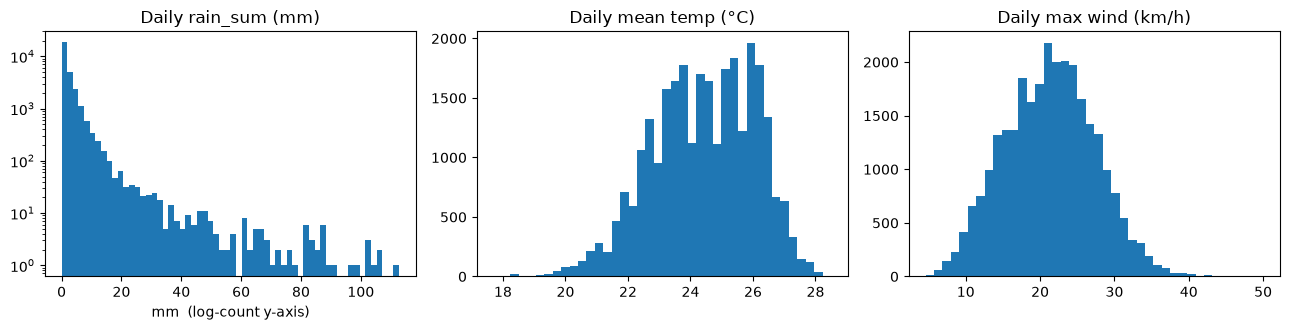

In [16]:
# --- 4.2b  EDA on the Open-Meteo weather itself (added per checkpoint feedback) ---
# This is the weather that actually feeds the model, so we summarize it here (it only
# exists after the parse above). Two-section file -> we look at the daily series `daily`.
print(daily[["rain", "temp", "wind"]].describe().round(2).to_string())
print("\nShare of dry days (rain < 1 mm):", round((daily["rain"] < 1).mean() * 100, 1), "%")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].hist(daily["rain"], bins=60); ax[0].set_yscale("log")
ax[0].set_title("Daily rain_sum (mm)"); ax[0].set_xlabel("mm  (log-count y-axis)")
ax[1].hist(daily["temp"], bins=40); ax[1].set_title("Daily mean temp (°C)")
ax[2].hist(daily["wind"], bins=40); ax[2].set_title("Daily max wind (km/h)")
plt.tight_layout(); plt.show()
# Rain is strongly zero-inflated: most days dry, a long right tail of storm days. That skew
# is expected and is exactly why we SUM rain over a window (the antecedent-rainfall feature).


In [17]:
# --- 4.3 Join weather to each sample, strictly from days up to the sample date ---
# Each beach is matched to its nearest Open-Meteo grid cell (fixed lookup; a couple
# of North-shore beaches share a cell). This is where the no-leakage rule lives:
# every feature uses only the sample day and the days before it.
# 4c . Engineered feature -- the REASON, stated before we build it:
#   Bacteria come from land runoff and overflowing drains, and that dirty water keeps reaching the
#   ocean for days after a storm. Rain on the sample day alone misses a big storm that ended two or
#   three days earlier, so we SUM the rain over the 7 days before the sample -> rain_prev_7days.
#   * Computed from y? No. It uses only Open-Meteo weather, so it can be computed for any future
#     day before anyone tests the water (no leakage).
#   * An exact combination of columns we already have? No. It adds up days d-7 .. d-1, and none
#     of those days is a column in X (rain_same_day is day d only), so the matrix stays non-singular.
SITE_TO_LOC = {858: 2, 859: 3, 776: 4, 861: 5, 777: 0, 8894: 1, 780: 6, 1197: 6, 8916: 8}

def weather_features(site_id, date):
    g   = by_loc[SITE_TO_LOC[int(site_id)]]
    d   = pd.Timestamp(date)
    ym1 = d - pd.Timedelta(days=1)
    same = g.loc[d] if d in g.index else None
    prev7 = g.loc[d - pd.Timedelta(days=7): ym1]           # the 7 days before the sample
    return pd.Series({
        "rain_same_day":   same.rain if same is not None else np.nan,
        "rain_prev_7days": round(prev7.rain.sum(), 1),
        "days_since_rain": float(g.loc[ym1, "dry_streak"]) if ym1 in g.index else np.nan,
        "temp_mean":       same.temp if same is not None else np.nan,
        "wind_max":        same.wind if same is not None else np.nan,
    })

feats = samples_beaches.apply(lambda r: weather_features(r.site_id, r.date), axis=1)
samples_beaches_weather = pd.concat([samples_beaches, feats], axis=1)
samples_beaches_weather.to_csv("samples_beaches_weather.csv", index=False)
samples_beaches_weather.head()

,sample_id,site_id,site_name,latitude,longitude,date,datetime_utc,enterococcus,ent_modifier,tide,unsafe,rain_same_day,rain_prev_7days,days_since_rain,temp_mean,wind_max
0,f60244e6-3c6f-4357-aa20-61a278577347,859,South Oʻahu: Magic Island Canoe Launch,21.287770,-157.844116,2026-09-06,2026-09-06T19:10:00.000Z,4611,=,incoming,1,6.4,11.2,0.0,26.3,20.0
1,d7ac771c-10eb-4761-a222-7ed87f5d5d6c,858,South Oʻahu: Magic Island Bowls,21.282953,-157.845657,2026-09-06,2026-09-06T19:00:00.000Z,327,=,incoming,1,6.4,11.2,0.0,26.3,20.0
2,ecb8b575-bcfd-4f9c-b8d8-1a2c128e29df,1197,North Oʻahu: Kaiaka Bay,21.590278,-158.119167,2026-09-06,2026-09-06T18:50:00.000Z,20,=,incoming,0,5.0,24.1,0.0,25.3,22.4
3,11d28250-2e4d-449e-a8b2-c937e99addf0,780,North Oʻahu: Pūpūkea tidepools,21.649846,-158.062988,2026-09-06,2026-09-06T18:00:00.000Z,98,=,incoming,0,5.0,24.1,0.0,25.3,22.4
4,5cd0965b-db92-46ad-a094-c11aa7cddb79,8894,East Oʻahu: Kailua Beach Park,21.397806,-157.726000,2026-09-06,2026-09-06T17:00:00.000Z,20,=,incoming,0,11.8,40.5,0.0,25.3,20.9


Correlation of each weather feature with log1p(enterococcus):
rain_same_day      0.248
rain_prev_7days    0.358
days_since_rain   -0.151
temp_mean         -0.258
wind_max           0.029

Unsafe rate by 7-day antecedent rainfall (mm):
              unsafe_pct    n
rain7_bucket                 
0-1                 15.9   44
1-10                18.7  563
10-25               29.2  377
25-50               50.7  211
50+                 71.6   74


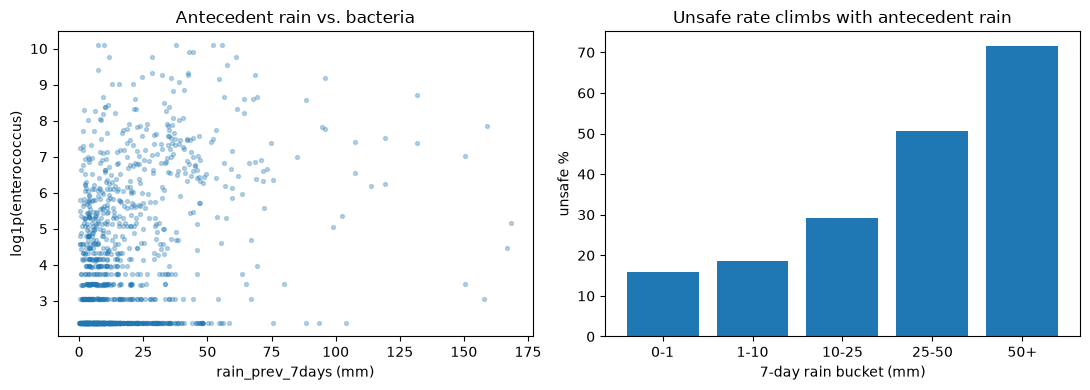


Average 7-day antecedent rain by beach (mm):
site_id
776     14.1
777     34.4
780     15.5
858     10.6
859     11.0
861     14.6
1197    15.0
8894    26.6
8916    16.9 
  all beaches: 17.8


In [18]:
# --- 4.3b  Weather features vs. enterococcus (does the weather actually relate to bacteria?) ---
# Core hypothesis: antecedent rainfall drives unsafe water. Now that weather is joined to each
# sample we check it directly -- correlation of each weather feature with the bacteria level,
# and how the unsafe rate changes across antecedent-rain buckets.
w = samples_beaches_weather.dropna(
    subset=["rain_same_day", "rain_prev_7days", "days_since_rain", "temp_mean", "wind_max"]).copy()
w["logent"] = np.log1p(w["enterococcus"])

wcols = ["rain_same_day", "rain_prev_7days", "days_since_rain", "temp_mean", "wind_max"]
print("Correlation of each weather feature with log1p(enterococcus):")
print(w[wcols + ["logent"]].corr()["logent"].drop("logent").round(3).to_string())

w["rain7_bucket"] = pd.cut(w["rain_prev_7days"], [-0.1, 1, 10, 25, 50, 1e9],
                           labels=["0-1", "1-10", "10-25", "25-50", "50+"])
tab = w.groupby("rain7_bucket", observed=True)["unsafe"].agg(
        unsafe_pct=lambda s: round(s.mean() * 100, 1), n="size")
print("\nUnsafe rate by 7-day antecedent rainfall (mm):")
print(tab.to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(w["rain_prev_7days"], w["logent"], s=8, alpha=.3)
ax[0].set_xlabel("rain_prev_7days (mm)"); ax[0].set_ylabel("log1p(enterococcus)")
ax[0].set_title("Antecedent rain vs. bacteria")
ax[1].bar(tab.index.astype(str), tab["unsafe_pct"])
ax[1].set_xlabel("7-day rain bucket (mm)"); ax[1].set_ylabel("unsafe %")
ax[1].set_title("Unsafe rate climbs with antecedent rain")
plt.tight_layout(); plt.show()

print("\nAverage 7-day antecedent rain by beach (mm):")
print(w.groupby("site_id")["rain_prev_7days"].mean().round(1).to_string(),
      f"\n  all beaches: {w['rain_prev_7days'].mean():.1f}")


In [19]:
# --- 4.4 Per-beach reference table (beaches.csv) ---
# The numeric columns are aggregated here; the descriptive ones (beach_name, region,
# full_site_name) are editorial labels, so they live in a small hand-kept lookup.
sb = samples_beaches.copy(); sb["year"] = sb.date.str[:4].astype(int)
agg = (sb.groupby("site_id")
         .agg(latitude=("latitude", "first"), longitude=("longitude", "first"),
              n_samples=("unsafe", "size"), n_unsafe=("unsafe", "sum"),
              first_year=("year", "min"), last_year=("year", "max"))
         .reset_index())
agg["unsafe_pct"] = (agg.n_unsafe / agg.n_samples * 100).round(1)

# The hand-kept lookup, in BEACH_SITE_IDS order (grouped by shore). The app's beach picker
# lists the beaches in this order.
BEACH_LABELS = pd.DataFrame([
    # site_id, beach_name, region, full_site_name
    (858,  "Magic Island – Bowls (Ala Moana)",        "South", "South Oʻahu: Magic Island Bowls"),
    (859,  "Magic Island – Canoe Launch (Ala Moana)", "South", "South Oʻahu: Magic Island Canoe Launch"),
    (776,  "Kaʻalāwai / Cromwell's",                  "South", "South Oʻahu: Kaʻalāwai (Black Point/Cromwells)"),
    (861,  "Waialae Beach Park",                      "South", "South Oʻahu: Waialae Beach Park"),
    (777,  "Kahaluʻu Beach",                          "East",  "East Oʻahu: Kahaluʻu Beach"),
    (8894, "Kailua Beach Park",                       "East",  "East Oʻahu: Kailua Beach Park"),
    (780,  "Pūpūkea tidepools / Shark's Cove",        "North", "North Oʻahu: Pūpūkea tidepools"),
    (1197, "Kaiaka Bay",                              "North", "North Oʻahu: Kaiaka Bay"),
    (8916, "Pōkaʻi Bay (Inside)",                     "West",  "West Oʻahu: Pōkaʻi Bay- Inside"),
], columns=["site_id", "beach_name", "region", "full_site_name"])

# merge with the curated labels to rebuild beaches.csv (the app reads it for the map and beach card)
beaches = BEACH_LABELS.merge(agg, on="site_id")       # keeps the lookup's row order
beaches = beaches[["site_id", "beach_name", "region", "full_site_name", "latitude", "longitude",
                   "n_samples", "n_unsafe", "unsafe_pct", "first_year", "last_year"]]
beaches.to_csv("beaches.csv", index=False)
print(beaches.shape)
print(beaches.drop(columns=["full_site_name", "latitude", "longitude"]).to_string(index=False))

(9, 11)
 site_id                              beach_name region  n_samples  n_unsafe  unsafe_pct  first_year  last_year
     858        Magic Island – Bowls (Ala Moana)  South        165        29        17.6        2019       2026
     859 Magic Island – Canoe Launch (Ala Moana)  South        168        68        40.5        2019       2026
     776                  Kaʻalāwai / Cromwell's  South        162        16         9.9        2018       2026
     861                      Waialae Beach Park  South        146        39        26.7        2019       2025
     777                          Kahaluʻu Beach   East        184       160        87.0        2018       2026
    8894                       Kailua Beach Park   East        112         9         8.0        2022       2026
     780        Pūpūkea tidepools / Shark's Cove  North        163        18        11.0        2018       2026
    1197                              Kaiaka Bay  North         92        38        41.3        

In [20]:
# --- 4.5 For the linear-regression model that follows (encode + scale + engineered feature) ---
# Target y = log1p(enterococcus)  (Part 2 showed the raw counts are ~log-normal).
# 4c New feature: rain_prev_7days (reason stated in 4.3). X_train_A omits it, X_train_B includes
#     it, per the Part 4 instructions.
from IPython.display import display

# Drop rows missing any model input (weather or tide) -> consistent drop-not-impute policy.
inputs  = ["rain_same_day", "rain_prev_7days", "days_since_rain", "temp_mean", "wind_max", "tide"]
dropped = samples_beaches_weather[samples_beaches_weather[inputs].isna().any(axis=1)]
model_df = samples_beaches_weather.dropna(subset=inputs).copy()
print(f"Dropped {len(dropped)} of {len(samples_beaches_weather)} rows; missing per input:",
      dropped[inputs].isna().sum()[lambda s: s > 0].to_dict())
print(f"mean log1p(ent): all rows {np.log1p(samples_beaches_weather.enterococcus).mean():.3f}"
      f" | kept {np.log1p(model_df.enterococcus).mean():.3f}"
      f" | dropped {np.log1p(dropped.enterococcus).mean():.3f}")

# y is its OWN dataframe (not a column inside X), aligned to model_df's index.
y = pd.DataFrame({"y": np.log1p(model_df["enterococcus"].to_numpy())}, index=model_df.index)

# temp_mean is kept as a genuine predictor, not just a rain proxy:
#   corr(temp_mean, logent) = -0.26; corr(temp_mean, rain_prev_7days) is only -0.22 but
#   corr(temp_mean, month) = +0.56, so it carries SEASONAL signal. It adds +0.024 R^2 beyond
#   the rain features alone, and its partial corr controlling for all rain features is still
#   -0.17. Mechanism: cooler days track Hawaii's wet season and bring less UV die-off of
#   bacteria, so colder water tends to carry higher enterococcus.

# 4a Encode -- which columns hold text or codes rather than quantities?
#   site_id : a code (858, 859, ...), not an amount -> NOMINAL (no beach is "more" than another).
#             9 levels (we filtered 63 sites down to 9, so no >20-level problem) -> 8 new columns.
#   tide    : 5 levels. high / medium / low describe the water LEVEL, incoming / outgoing the
#             DIRECTION -- two different ideas, so there is no single order -> NOMINAL -> 4 columns.
#   binary  : none among the inputs (ent_modifier is not an input; unsafe is computed from y).
# drop_first=True drops one level per group -- reference = site 1197 (Kaiaka Bay) and tide "high" --
# so the dummies can't add up to the intercept's column of ones (the dummy-variable trap).
X_site = pd.get_dummies(model_df[["site_id"]].astype(str), drop_first=True)   # nominal
X_tide = pd.get_dummies(model_df[["tide"]], prefix="tide", drop_first=True)   # nominal (kept per 3b-ii)
print(f"site_id: {model_df.site_id.nunique()} levels -> {X_site.shape[1]} columns added")
print(f"tide   : {model_df.tide.nunique()} levels -> {X_tide.shape[1]} columns added")
cont   = ["rain_same_day", "days_since_rain", "temp_mean", "wind_max"]        # A: without rain_prev_7days
X_train_A = pd.concat([X_site, X_tide, model_df[cont]], axis=1)
X_train_B = pd.concat([X_site, X_tide, model_df[cont + ["rain_prev_7days"]]], axis=1)  # B: + engineered


Dropped 18 of 1269 rows; missing per input: {'tide': 18}
mean log1p(ent): all rows 4.028 | kept 4.037 | dropped 3.445
site_id: 9 levels -> 8 columns added
tide   : 5 levels -> 4 columns added


In [21]:
# 4b Scale -- range of every column after cleaning + encoding, BEFORE scaling:
scale_cols = cont + ["rain_prev_7days"]
print(pd.concat([X_site, X_tide, model_df[scale_cols]], axis=1).astype(float)
        .agg(["min", "max"]).T.to_string())

# Method: standardization (z-score, (x - mean) / std) on the continuous columns.
#   Why: rain_prev_7days runs 0-168 while temp_mean runs 18-28. With one learning rate, gradient
#   descent crawls along the big-range columns and overshoots on the small ones. After z-scoring
#   every column has mean 0 / std 1, and turning a weight back into real units is just w / std.
#   Why not min-max: rare storm values (168 mm) would squash almost every normal day into 0-0.1.
#   Why not robust (median/IQR): days_since_rain has median 0 and IQR 2, so its 44-day dry spells
#   would become 22 "units" -- a new scale mismatch.
# One-hot columns: NOT scaled. They are already 0/1, about the same size as z-scores, and left
#   unscaled each weight reads directly as "this beach / tide vs. the reference level".
mu, sigma = model_df[scale_cols].mean(), model_df[scale_cols].std()
for Xt in (X_train_A, X_train_B):
    for c in [c for c in scale_cols if c in Xt]:
        Xt[c] = (model_df[c] - mu[c]) / sigma[c]      # from the raw values, so re-running is safe

# STORE the scaler's numbers: a new row must be scaled with exactly these values before predicting.
scaler = pd.DataFrame({"mean": mu, "std": sigma})
print("\nScaler (kept in `scaler` / `mu` / `sigma`):\n", scaler.round(3).to_string())
print("\nAfter scaling:\n", X_train_B[scale_cols].agg(["mean", "std", "min", "max"]).T.round(2).to_string())


                  min    max
site_id_776       0.0    1.0
site_id_777       0.0    1.0
site_id_780       0.0    1.0
site_id_858       0.0    1.0
site_id_859       0.0    1.0
site_id_861       0.0    1.0
site_id_8894      0.0    1.0
site_id_8916      0.0    1.0
tide_incoming     0.0    1.0
tide_low          0.0    1.0
tide_medium       0.0    1.0
tide_outgoing     0.0    1.0
rain_same_day     0.0   47.5
days_since_rain   0.0   44.0
temp_mean        17.7   28.5
wind_max          5.5   50.0
rain_prev_7days   0.0  168.4

Scaler (kept in `scaler` / `mu` / `sigma`):
                    mean     std
rain_same_day     2.485   4.061
days_since_rain   1.801   3.590
temp_mean        24.288   1.634
wind_max         21.626   6.004
rain_prev_7days  17.752  20.687

After scaling:
                  mean  std   min    max
rain_same_day     0.0  1.0 -0.61  11.08
days_since_rain   0.0  1.0 -0.50  11.76
temp_mean         0.0  1.0 -4.03   2.58
wind_max         -0.0  1.0 -2.69   4.73
rain_prev_7days   0.0  

In [22]:
# Verify the merge: same rows, aligned index, y separate. Show shape + head of A, B, and y.
for name, d in [("X_train_A", X_train_A), ("X_train_B", X_train_B), ("y", y)]:
    print(f"{name}.shape = {d.shape}")
print("Same row count & aligned index:",
      len(X_train_A) == len(X_train_B) == len(y) and X_train_A.index.equals(y.index))
print("\nX_train_A.head():"); display(X_train_A.head())
print("X_train_B.head():"); display(X_train_B.head())
print("y.head():");          display(y.head())

# No two continuous inputs are highly correlated (largest |r| is about 0.27), so no more columns
# need removing, and rain_prev_7days is not a near-copy of rain_same_day.
print("Correlation between the continuous inputs:")
print(model_df[scale_cols].corr().round(2).to_string())


X_train_A.shape = (1251, 16)
X_train_B.shape = (1251, 17)
y.shape = (1251, 1)
Same row count & aligned index: True

X_train_A.head():


,site_id_776,site_id_777,site_id_780,site_id_858,site_id_859,site_id_861,site_id_8894,site_id_8916,tide_incoming,tide_low,tide_medium,tide_outgoing,rain_same_day,days_since_rain,temp_mean,wind_max
0,False,False,False,False,True,False,False,False,True,False,False,False,0.963861,-0.501702,1.231164,-0.270727
1,False,False,False,True,False,False,False,False,True,False,False,False,0.963861,-0.501702,1.231164,-0.270727
2,False,False,False,False,False,False,False,False,True,False,False,False,0.619153,-0.501702,0.619202,0.128974
3,False,False,True,False,False,False,False,False,True,False,False,False,0.619153,-0.501702,0.619202,0.128974
4,False,False,False,False,False,False,True,False,True,False,False,False,2.293451,-0.501702,0.619202,-0.120840


X_train_B.head():


,site_id_776,site_id_777,site_id_780,site_id_858,site_id_859,site_id_861,site_id_8894,site_id_8916,tide_incoming,tide_low,tide_medium,tide_outgoing,rain_same_day,days_since_rain,temp_mean,wind_max,rain_prev_7days
0,False,False,False,False,True,False,False,False,True,False,False,False,0.963861,-0.501702,1.231164,-0.270727,-0.316724
1,False,False,False,True,False,False,False,False,True,False,False,False,0.963861,-0.501702,1.231164,-0.270727,-0.316724
2,False,False,False,False,False,False,False,False,True,False,False,False,0.619153,-0.501702,0.619202,0.128974,0.306859
3,False,False,True,False,False,False,False,False,True,False,False,False,0.619153,-0.501702,0.619202,0.128974,0.306859
4,False,False,False,False,False,False,True,False,True,False,False,False,2.293451,-0.501702,0.619202,-0.120840,1.099631


y.head():


,y
0,8.436417
1,5.793014
2,3.044522
3,4.595120
4,3.044522


Correlation between the continuous inputs:
                 rain_same_day  days_since_rain  temp_mean  wind_max  rain_prev_7days
rain_same_day             1.00            -0.17      -0.21      0.06             0.26
days_since_rain          -0.17             1.00       0.11     -0.05            -0.27
temp_mean                -0.21             0.11       1.00      0.00            -0.22
wind_max                  0.06            -0.05       0.00      1.00            -0.04
rain_prev_7days           0.26            -0.27      -0.22     -0.04             1.00


---
## Part 5: Gradient Descent

25 pts

Write your gradient descent functions

In [23]:
def compute_cost(X, y, w, b):
    """X (m,n), y (m,), w (n,), b float -> float"""
    m = X.shape[0]
    err = X @ w + b - y          # residual for every row at once
    return (err @ err) / (2 * m) # mean squared error, halved

def compute_gradient(X, y, w, b):
    """-> dj_dw (n,), dj_db (float)"""
    m = X.shape[0]
    err = X @ w + b - y          # (m,)
    dj_dw = (X.T @ err) / m      # (n,) — one slope per feature
    dj_db = err.mean()           # scalar
    return dj_dw, dj_db

def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    """-> w (n,), b (float), J_history (list)"""
    w = w_in.astype(float).copy()
    b = float(b_in)
    J_history = []
    for _ in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw    # step downhill on every weight
        b = b - alpha * dj_db
        J_history.append(compute_cost(X, y, w, b))
    return w, b, J_history

Changes from the previous univariate version:

- `w` is now an array of length `n`, is greater than 1
- `f = X @ w + b` predicts all `m` rows at once
- `dj_dw` is an array of length `n`: `X.T @ (f - y) / m`
- `dj_db` is still one number: `(f - y).mean()`

---
## Part 6: Building the models

Build three models: `baseline` (define what your baseline means), a model build using `X_train_A`, and another model using `X_train_B`.

Per feedback, we also add a **second baseline** that predicts each site's own average, since `site_id` turned out to be the strongest feature.


In [24]:
# Feature matrices as plain float arrays (one-hot columns come out as bool).
XA = X_train_A.to_numpy(dtype=float)
XB = X_train_B.to_numpy(dtype=float)
y_vec = y["y"].to_numpy(dtype=float)           # target array, pulled from the y DataFrame (Part 4.5)

# --- Baseline: NO features. The best you can do with a single constant is to
#     predict the mean of y for every row. That's our "do-nothing" reference. ---
baseline_J = ((y_vec - y_vec.mean()) ** 2).mean() / 2

# --- Model A: site + tide + weather, WITHOUT the engineered feature ---
wA, bA, histA = gradient_descent(XA, y_vec, np.zeros(XA.shape[1]), 0.0,
                                 alpha=0.3, num_iters=3000)
JA = compute_cost(XA, y_vec, wA, bA)

# --- Model B: same, PLUS rain_prev_7days ---
wB, bB, histB = gradient_descent(XB, y_vec, np.zeros(XB.shape[1]), 0.0,
                                 alpha=0.3, num_iters=3000)
JB = compute_cost(XB, y_vec, wB, bB)

print(f"baseline J = {baseline_J:.4f}")
print(f"Model A  J = {JA:.4f}")
print(f"Model B  J = {JB:.4f}")


baseline J = 1.8890
Model A  J = 1.0468
Model B  J = 0.9902


In [25]:
# --- Second baseline: predict each SITE's average y (no weather, no tide) ---
# Same idea as the first baseline, but one constant per beach instead of one for everyone:
# every Kahaluʻu prediction is Kahaluʻu's mean, every Kailua prediction is Kailua's mean.
# Like the first baseline (and Models A/B), it is measured on the same rows it was fit on.
site_mean = y["y"].groupby(model_df["site_id"]).transform("mean").to_numpy()
site_baseline_J = ((y_vec - site_mean) ** 2).mean() / 2
print(f"site-mean baseline J = {site_baseline_J:.4f}")
print(model_df.assign(y=y_vec).groupby("site_id")["y"].agg(["mean", "size"]).round(3).to_string())

site-mean baseline J = 1.1509
          mean  size
site_id             
776      3.010   158
777      6.596   183
780      3.167   157
858      3.503   164
859      4.689   167
861      3.735   145
1197     4.571    91
8894     2.998   110
8916     2.965    76


In [26]:
print("Model A weights:\n", pd.Series(wA, index=X_train_A.columns).round(3).to_string())
print("\nModel B weights:\n", pd.Series(wB, index=X_train_B.columns).round(3).to_string())


Model A weights:
 site_id_776       -1.511
site_id_777        1.765
site_id_780       -1.383
site_id_858       -0.831
site_id_859        0.336
site_id_861       -0.736
site_id_8894      -1.690
site_id_8916      -1.378
tide_incoming      0.010
tide_low           0.135
tide_medium       -0.494
tide_outgoing      0.019
rain_same_day      0.219
days_since_rain   -0.176
temp_mean         -0.299
wind_max           0.074

Model B weights:
 site_id_776       -1.513
site_id_777        1.462
site_id_780       -1.399
site_id_858       -0.816
site_id_859        0.349
site_id_861       -0.755
site_id_8894      -1.866
site_id_8916      -1.440
tide_incoming     -0.120
tide_low           0.067
tide_medium       -0.537
tide_outgoing     -0.061
rain_same_day      0.179
days_since_rain   -0.112
temp_mean         -0.245
wind_max           0.078
rain_prev_7days    0.382


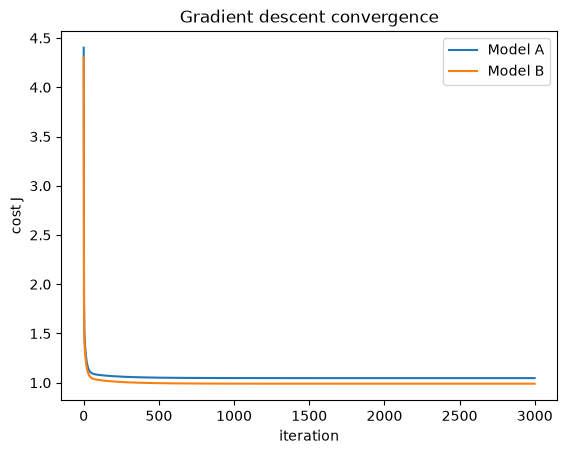

In [27]:
# Convergence check — both curves should flatten out well before 3000 iters.
plt.plot(histA, label="Model A")
plt.plot(histB, label="Model B")
plt.xlabel("iteration"); plt.ylabel("cost J"); plt.legend(); plt.title("Gradient descent convergence")
plt.show()

### 6b · Choosing the learning rate α

Two questions: does α = 0.3 actually converge, and is it the best choice?

**How we check convergence.** A flat cost curve is a hint, not proof: the curve can look flat while still creeping down. Linear regression has an exact answer, the *normal equation*, which solves for the weights directly with no iterations. We compute that minimum cost J\* with `np.linalg.lstsq` and measure how far gradient descent's final J is from it. If the gap is around 10⁻⁶ or smaller, gradient descent has found the same minimum.

**Why there's an upper limit on α.** For this cost, gradient descent only converges if α < 2 / λ_max, where λ_max is the largest eigenvalue of XᵀX / m (with a column of ones for the intercept). Above that, every step overshoots the bottom of the bowl by more than it gained, and J blows up. The fastest fixed step is about 2 / (λ_max + λ_min).

Below we run both models with eight values of α for 3000 iterations each.


Model A: exact minimum J* = 1.046805 | lambda_max = 1.427, lambda_min = 0.0074
  converges only if alpha < 2/lambda_max = 1.40; fastest fixed step 2/(lambda_max+lambda_min) = 1.39
   alpha   J after 3000   gap to J*   iters until gap < 1e-6


   0.001       1.381477    3.35e-01                  not yet


   0.010       1.079677    3.29e-02                  not yet


   0.100       1.047295    4.90e-04                  not yet


   0.300       1.046805    6.50e-08                     2388


...

   0.300       0.990177    7.85e-08                     2428


   0.500       0.990177    1.07e-11                     1456


   1.000       0.990177    0.00e+00                      727


   1.300            inf         inf                 diverged


   1.500            inf         inf                 diverged


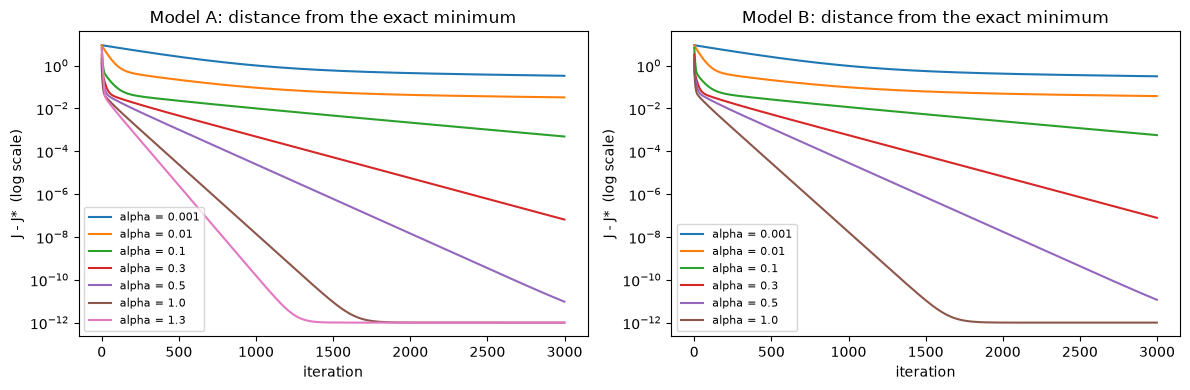

In [28]:
# --- 6b Learning-rate sweep: same starting point, 3000 iterations, different alpha ---
m = XA.shape[0]
alphas = [0.001, 0.01, 0.1, 0.3, 0.5, 1.0, 1.3, 1.5]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, X) in zip(axes, [("Model A", XA), ("Model B", XB)]):
    X1 = np.hstack([X, np.ones((m, 1))])                       # ones column = the intercept b
    coef, *_ = np.linalg.lstsq(X1, y_vec, rcond=None)          # exact least-squares solution
    J_star = ((X1 @ coef - y_vec) ** 2).mean() / 2
    eig = np.linalg.eigvalsh(X1.T @ X1 / m)
    print(f"\n{name}: exact minimum J* = {J_star:.6f} | lambda_max = {eig.max():.3f}, lambda_min = {eig.min():.4f}")
    print(f"  converges only if alpha < 2/lambda_max = {2 / eig.max():.2f}; "
          f"fastest fixed step 2/(lambda_max+lambda_min) = {2 / (eig.max() + eig.min()):.2f}")
    print(f"  {'alpha':>6s} {'J after 3000':>14s} {'gap to J*':>11s} {'iters until gap < 1e-6':>24s}")
    for a in alphas:
        with np.errstate(over="ignore", invalid="ignore"):
            _, _, hist = gradient_descent(X, y_vec, np.zeros(X.shape[1]), 0.0, a, 3000)
        hist = np.array(hist)
        ok = np.isfinite(hist[-1]) and hist[-1] < 1e3
        hit = np.flatnonzero(hist - J_star < 1e-6)
        gap = max(hist[-1] - J_star, 0.0) if ok else float("inf")   # clip float round-off below 0
        print(f"  {a:6.3f} {hist[-1] if ok else float('inf'):14.6f} {gap:11.2e} "
              f"{(str(hit[0] + 1) if hit.size else ('diverged' if not ok else 'not yet')):>24s}")
        if ok:
            ax.plot(hist - J_star + 1e-12, label=f"alpha = {a}")
    ax.set_yscale("log"); ax.set_xlabel("iteration"); ax.set_ylabel("J - J*  (log scale)")
    ax.set_title(f"{name}: distance from the exact minimum"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**What the sweep shows**

- **α = 0.3 converges.** After 3000 iterations both models are within about 10⁻⁷ of the exact minimum J\* from the normal equation, and they get within 10⁻⁶ after roughly 2,400 iterations. So the weights and costs reported in Part 6 are the true least-squares answer, not a half-finished descent.
- **α = 0.3 is safe but not the fastest.** Every α that converges ends at the *same* J\*, so the learning rate changes how fast we get there, not where we end up. Larger steps get there sooner: α = 1.0 needs about 720 iterations instead of about 2,400. Too small is slow: after 3000 iterations, α = 0.01 is still about 0.03 above the minimum and α = 0.001 about 0.3 above.
- **Too large diverges.** The limit is 2 / λ_max ≈ 1.40 for Model A and ≈ 1.20 for Model B (B's extra rain column makes the bowl steeper in one direction). That's why α = 1.3 works for A but not for B, and α = 1.5 blows up for both.
- **Why so many iterations at all?** λ_min is tiny (≈ 0.007) compared with λ_max (≈ 1.4–1.7). The bowl is long and narrow in one direction, mostly because the dummy columns for small sites are rarely 1, and gradient descent creeps slowly along that narrow valley. Standardizing the continuous columns (Part 4b) already helped. Without it, the rain and temperature columns would make the bowl far more lopsided.

**Is 0.3 optimal?** For *speed*, no: about 1.0–1.2 is the fastest choice that still converges for both models. For the *result*, it makes no difference, because every converging α reaches the same minimum. We kept α = 0.3 because it converges with a wide safety margin below both limits, and 3000 iterations is cheap here.

In [29]:
# J = half the mean squared error, in (log units)^2. sqrt(2J) = RMSE is back in the units of y.
# Two reference points: the overall mean (baseline 1) and each site's own mean (baseline 2).
rows = [("Baseline 1", "overall mean",          baseline_J),
        ("Baseline 2", "site mean",             site_baseline_J),
        ("Model A",    "original only",         JA),
        ("Model B",    "original + engineered", JB)]
print(f"{'model':11s} {'features':22s} {'J':>8s} {'removed vs B1':>14s} {'removed vs B2':>14s} {'RMSE (y units)':>15s}")
for name, feats, J in rows:
    print(f"{name:11s} {feats:22s} {J:8.4f} {1 - J/baseline_J:14.4f} {1 - J/site_baseline_J:14.4f} "
          f"{np.sqrt(2 * J):15.3f}")

model       features                      J  removed vs B1  removed vs B2  RMSE (y units)
Baseline 1  overall mean             1.8890         0.0000        -0.6413           1.944
Baseline 2  site mean                1.1509         0.3907         0.0000           1.517
Model A     original only            1.0468         0.4458         0.0904           1.447
Model B     original + engineered    0.9902         0.4758         0.1396           1.407


In [30]:
# Weights back in REAL units (for Part 7). The continuous columns were standardized, so
# weight per real unit = w / sigma. Dummies were never scaled, so their weight already means
# "this level vs. the reference level". y is log1p(count), so exp(weight) is the factor the
# bacteria count gets multiplied by, holding the other features fixed.
units = {"rain_same_day": "mm", "days_since_rain": "day", "temp_mean": "°C",
         "wind_max": "km/h", "rain_prev_7days": "mm"}
for name, X, w, b in [("Model A", X_train_A, wA, bA), ("Model B", X_train_B, wB, bB)]:
    print(f"\n{name}: intercept b = {b:.3f}  (reference beach and tide, average weather "
          f"-> about {np.expm1(b):.0f} MPN/100mL)")
    for col, wv in zip(X.columns, w):
        if col in units:
            per = wv / sigma[col]
            print(f"  {col:16s} {per:+.4f} per {units[col]:4s} -> count x{np.exp(per):.3f}")
        else:
            print(f"  {col:16s} {wv:+.3f} vs reference -> count x{np.exp(wv):.2f}")



Model A: intercept b = 4.517  (reference beach and tide, average weather -> about 91 MPN/100mL)
  site_id_776      -1.511 vs reference -> count x0.22
  site_id_777      +1.765 vs reference -> count x5.84
  site_id_780      -1.383 vs reference -> count x0.25
  site_id_858      -0.831 vs reference -> count x0.44
  site_id_859      +0.336 vs reference -> count x1.40
  site_id_861      -0.736 vs reference -> count x0.48
  site_id_8894     -1.690 vs reference -> count x0.18
  site_id_8916     -1.378 vs reference -> count x0.25
  tide_incoming    +0.010 vs reference -> count x1.01
  tide_low         +0.135 vs reference -> count x1.14
  tide_medium      -0.494 vs reference -> count x0.61
  tide_outgoing    +0.019 vs reference -> count x1.02
  rain_same_day    +0.0538 per mm   -> count x1.055
  days_since_rain  -0.0491 per day  -> count x0.952
  temp_mean        -0.1832 per °C   -> count x0.833
  wind_max         +0.0123 per km/h -> count x1.012

Model B: intercept b = 4.664  (reference beach

---
## Part 7: Model evaluation

10 pts

Compare models and report weights in real units (not scaled versions).

| model      | features              | J      | cost removed vs baseline 1 (overall mean) | cost removed vs baseline 2 (site mean) |
|------------|-----------------------|--------|------:|------:|
| Baseline 1 | none: overall mean    | 1.8890 | 0.0000 | – |
| Baseline 2 | site_id only: each site's mean | 1.1509 | 0.3907 | 0.0000 |
| Model A    | original only         | 1.0468 | 0.4458 | 0.0904 |
| Model B    | original + engineered | 0.9902 | 0.4758 | 0.1396 |

where `cost removed = 1 - J / baseline_J` for the baseline in that column.

**What the second baseline shows.** Just knowing *which beach* removes 39% of the cost, before any weather or tide. That's most of what Model A and Model B achieve (45% and 48%). Measured against the site-mean baseline, the weather and tide columns remove a further **9% (Model A)** and **14% (Model B)** of the cost that the beach alone leaves behind. In RMSE terms, the beach alone takes the typical error from 1.944 to 1.517 log units, and Model B's weather columns take it from 1.517 to 1.407. So the beach does most of the work, weather is a real but smaller second effect, and the engineered 7-day rain feature is the biggest part of that weather effect: it lifts the gain over baseline 2 from 9% to 14%. This matches the app, which tells users "the beach does most of the work."


1. **Did Model A beat the baseline?** By how much, in the units of `y`?

Yes. Model A cut J from 1.8890 to 1.0468, which removes 45% of the cost. J is half the mean squared error, so to get back to the units of y we use the RMSE, √(2J). The typical error fell from 1.944 to 1.447 log₁p(MPN/100 mL), which is **0.50 log units smaller**. Because y is a log, this means a typical prediction used to be off by a factor of about e^1.94 ≈ 7× and is now off by about e^1.45 ≈ 4×.

2. **Did Model B beat Model A?**

Yes, but only by a little. B removed 0.03 more of the cost (0.4758 vs. 0.4458): J fell from 1.0468 to 0.9902, and RMSE fell from 1.447 to 1.407 log₁p(MPN/100 mL).

3. **Could question 2 have come out the other way?** Think carefully before answering.

On the training data, no. Model B has every column Model A has, plus rain_prev_7days. B could always set that one weight to 0 and copy Model A exactly, so B's best possible J can never be worse than A's. The only way B could lose on training cost is if gradient descent stopped before converging, and Part 6b shows both models end within about 10⁻⁷ of the exact least-squares minimum, so neither stopped early.

On new data, yes it could. We measured J on the same rows we trained on, so part of B's 0.03 gain could be fitting noise. The gain is small, and the dataset is small (1,251 rows), so on a different sample or on held-out recent years B could tie or even lose to A. To really know, we would compare them on a test set the models never saw.

4. **Compare your Part 2 ranking to your fitted weights.** Which features did you expect to matter that did not? Which mattered that you did not expect? Do not edit your Step 2 answer

Part 2's instructions didn't ask for an explicit feature ranking, so we use the one from our EDA in 4.3b, made before any model was fit. It ranks the weather features by their correlation with log₁p(enterococcus): 7-day rain (+0.36) > temperature (−0.26) ≈ same-day rain (+0.25) > days since rain (−0.15) > wind (+0.03). Since the continuous columns are standardized, Model B's weights can be ranked the same way: 7-day rain (+0.382) > temperature (−0.245) > same-day rain (+0.179) > days since rain (−0.112) > wind (+0.078). The order and the signs match, which supports our expectation that rainfall matters most.

*Expected to matter but didn't:* **tide.** In 3b(ii), outgoing tides had the highest unsafe rate (37.8% vs. 21.1% for medium), but in Model B outgoing is only ×0.94 vs. high tide, which is basically no effect. That 3b(ii) pattern was measured over all 63 sites. Within our 9 swim beaches the unsafe rate barely changes with tide (27–33%), so once the model knows the beach, tide adds little. Days since rain also shrank (−0.176 in A → −0.112 in B) once 7-day rain was added, because the two overlap (r = −0.27).

*Mattered but we didn't expect it:* **the beach itself.** The site weights are the biggest in the model. Holding weather and tide the same, Kahaluʻu is predicted at ×4.3 the bacteria of Kaiaka Bay and Kailua at ×0.15, a gap of about 28× between beaches. That is far larger than any single weather effect. Wind also came out slightly positive even though its correlation was about 0.



**Report the weights** with their real units. "One additional bedroom is associated with a price $32,904 lower, among houses of the same size" is a result. "w_3 = -32.9" is not.

Continuous weights are converted back with w / σ (σ from the scaler in 4b). Dummy weights were never scaled, so they already mean "compared with the reference level" (Kaiaka Bay, high tide). Since y = log₁p(count), e^w is the factor the bacteria count is multiplied by. Every statement below holds the other features the same. (Full printout: last cell of Part 6.)

**Model B** (intercept b = 4.664, i.e. about 105 MPN/100 mL at Kaiaka Bay, high tide, average weather)

- Same-day rain: +0.179 / 4.061 = **+0.0440 log₁p(MPN/100 mL) per mm**. Each extra mm of rain on the sample day goes with about 4.5% more enterococcus.
- 7-day rain: +0.382 / 20.687 = **+0.0185 per mm**. Each extra mm over the previous week goes with about 1.9% more, so a week about 21 mm wetter (one σ) goes with about ×1.47.
- Days since rain: −0.112 / 3.590 = **−0.0311 per day**. Each extra dry day goes with about 3.1% less.
- Temperature: −0.245 / 1.634 = **−0.1501 per °C**. A day 1 °C warmer goes with about 14% less.
- Wind: +0.078 / 6.004 = **+0.0130 per km/h**. Each extra km/h of max wind goes with about 1.3% more.
- Beach vs. Kaiaka Bay: Kahaluʻu +1.462 (×4.32), Magic Island Canoe Launch +0.349 (×1.42), Magic Island Bowls −0.816 (×0.44), Waialae −0.755 (×0.47), Pūpūkea −1.399 (×0.25), Pōkaʻi Bay −1.440 (×0.24), Kaʻalāwai −1.513 (×0.22), Kailua −1.866 (×0.15).
- Tide vs. high: medium −0.537 (×0.58), incoming −0.120 (×0.89), outgoing −0.061 (×0.94), low +0.067 (×1.07).

**Model A** (intercept b = 4.517, i.e. about 91 MPN/100 mL)

- Same-day rain: +0.219 / 4.061 = **+0.0538 per mm** (about 5.5% more per mm).
- Days since rain: −0.176 / 3.590 = **−0.0491 per day** (about 4.8% less per dry day).
- Temperature: −0.299 / 1.634 = **−0.1832 per °C** (about 17% less per °C warmer).
- Wind: +0.074 / 6.004 = **+0.0123 per km/h** (about 1.2% more per km/h).
- Beach vs. Kaiaka Bay: Kahaluʻu +1.765 (×5.84), Canoe Launch +0.336 (×1.40), Bowls −0.831 (×0.44), Waialae −0.736 (×0.48), Pūpūkea −1.383 (×0.25), Pōkaʻi Bay −1.378 (×0.25), Kaʻalāwai −1.511 (×0.22), Kailua −1.690 (×0.18).
- Tide vs. high: medium −0.494 (×0.61), incoming +0.010, outgoing +0.019, low +0.135 (×1.14).

Without 7-day rain, Model A gives more credit to same-day rain, days since rain, and Kahaluʻu. Kahaluʻu's samples average 34 mm of rain in the week before, vs. 18 mm overall. Part of those Model A weights was really the antecedent-rain effect.
